# Diagnostics & results (seed-aware)

Set **`SEEDS`** once in the Configuration cell; every section then overlays all
of those seeds on each plot:

1. Compressor (stage-1) training curves — all seeds
2. NLE (stage-2) training curves — all seeds
3. Final evaluation (stage 4): SBC, corner, metrics — all seeds

Run this **on `tycho`** (VS Code tunnel) so it can see scratch data. Edit the
**Configuration** cell, then *Run All*.

> These sections read what stages 1-3 already wrote to scratch; they launch no
> jobs. Save this notebook **with outputs** to publish the figures in the book.

### Setup

In [1]:
import os, glob, subprocess
from pathlib import Path
from IPython.display import Image, display

REPO = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(REPO)
OUT = Path("notebooks/_figs")
OUT.mkdir(parents=True, exist_ok=True)


def show(path):
    """Display a PNG, or rasterize+show the first page of a PDF (needs pdftoppm)."""
    p = str(path)
    if p.endswith(".png") and os.path.exists(p):
        display(Image(p))
        return
    if p.endswith(".pdf") and os.path.exists(p):
        prev = p[:-4] + "_preview"
        if os.system(
            f'pdftoppm -png -r 110 -singlefile "{p}" "{prev}" 2>/dev/null'
        ) == 0 and os.path.exists(prev + ".png"):
            display(Image(prev + ".png"))
            return
    print("figure:", p)


print("working dir:", REPO)

working dir: /obs/ddehiwalage-don/21cm/sbi_project


### Configuration — edit these
`SEEDS` is the list overlaid in every plot. Per-seed output dirs are derived
from the config exactly the way stages 1-3 name them: `<scratch_root>/<arm_name>_s<seed>/`.

In [2]:
import yaml

CONFIG = "configs_seeds/noise/arm_cnn_vmim_no_jitter_n1.yaml"  # the arm's config YAML
SEEDS = [0, 1, 2]  # <-- seeds to overlay in EVERY plot
FAMILY = "nsf"  # density family from stage 2 (gmm | maf | nsf)
SCOPE = "std"  # 'std' (standardized t) or 'raw'
LABEL = "VMIM n4"  # base legend label (' s<seed>' is appended per seed)
NAMES = "Fx tau rHS Mmin"  # physical parameter names (compressor plot legend)

# derive per-seed dirs from the config (same layout stages 1-3 write)
_cfg = yaml.safe_load(open(CONFIG))
SCRATCH_ROOT = _cfg["scratch_root"]
ARM_NAME = _cfg["arm_name"]  # raw template, e.g. cnn_vmim_/n4/seed


def seed_nle_dir(s):
    return f"{SCRATCH_ROOT}/{ARM_NAME}_s{s}/nle"


print("overlaying seeds", SEEDS, "for arm", ARM_NAME)
for s in SEEDS:
    d = seed_nle_dir(s)
    print(f"  s{s}: {d}   {'OK' if os.path.isdir(d) else '** MISSING **'}")

overlaying seeds [0, 1, 2] for arm cnn_vmim_/n1/seed
  s0: /gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s0/nle   OK
  s1: /gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s1/nle   OK
  s2: /gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s2/nle   OK


## 1. Compressor training (all seeds overlaid)
One `label=path` per seed → `plot_training_compressor.py` overlays them.

wrote notebooks/_figs/compressor.pdf
wrote notebooks/_figs/compressor.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  s0                      0.983     0.938     0.897     0.936
  s1                      0.989     0.940     0.897     0.961
  s2                      0.973     0.938     0.922     0.953

final RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  s0                      0.974     0.921     0.897     0.919
  s1                      0.967     0.931     0.897     0.934
  s2                      0.960     0.906     0.922     0.930

RF-R2 at best-probe checkpoint (the one exported):
  arm                        Fx       tau       rHS      Mmin
  s0                      0.976     0.929     0.889     0.935
  s1                      0.989     0.934     0.869     0.944
  s2                      0.966     0.938     0.912     0.946

final sigma(theta_p|t)  [prior 0.289]:
  arm                        Fx

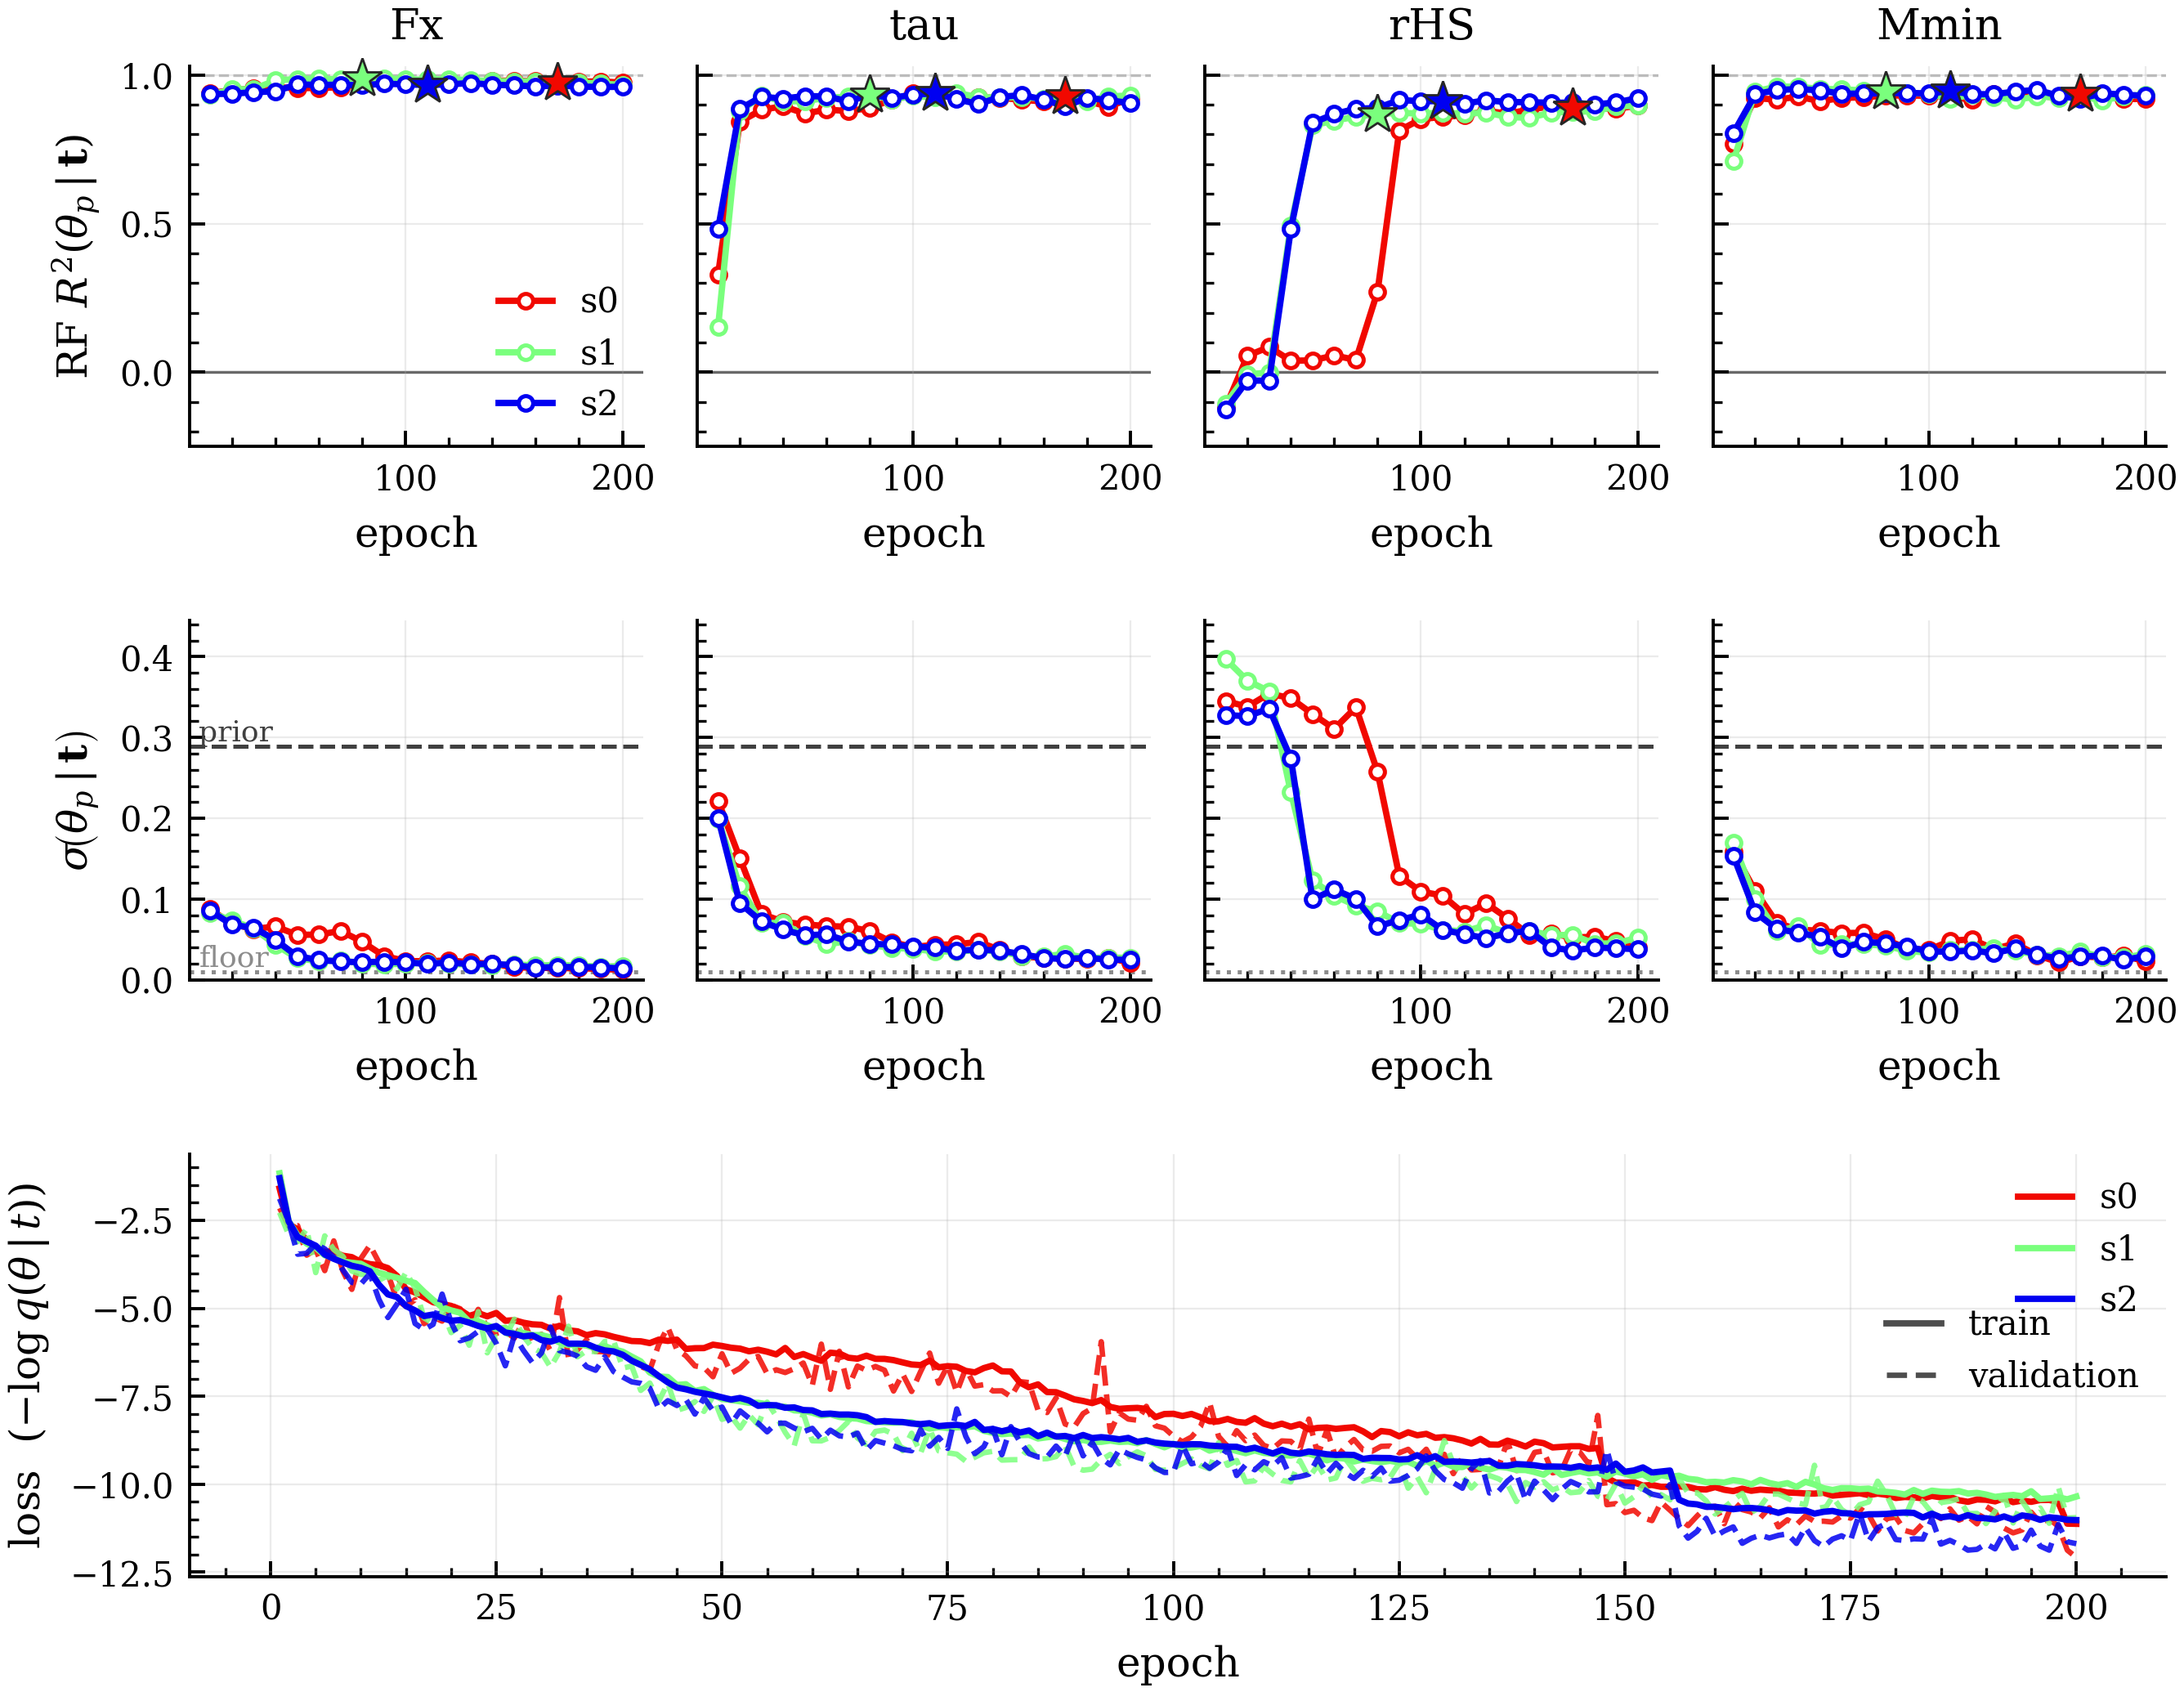

In [3]:
arms = " ".join(f"s{s}={seed_nle_dir(s)}" for s in SEEDS)
fig = OUT / "compressor.pdf"
!python tools/plot_training_compressor.py {arms} --names {NAMES} --out "{fig}" --png
show(fig.with_suffix(".png"))

## 2. NLE training (all seeds overlaid)
`plot_training_nle.py` discovers the seeds itself via `--seeds`.

[arm_cnn_vmim_no_jitter_n1] discovered seeds=[0, 1, 2]  with loss data=[0, 1, 2]

[SUCCESS] wrote notebooks/_figs/nle_training.png


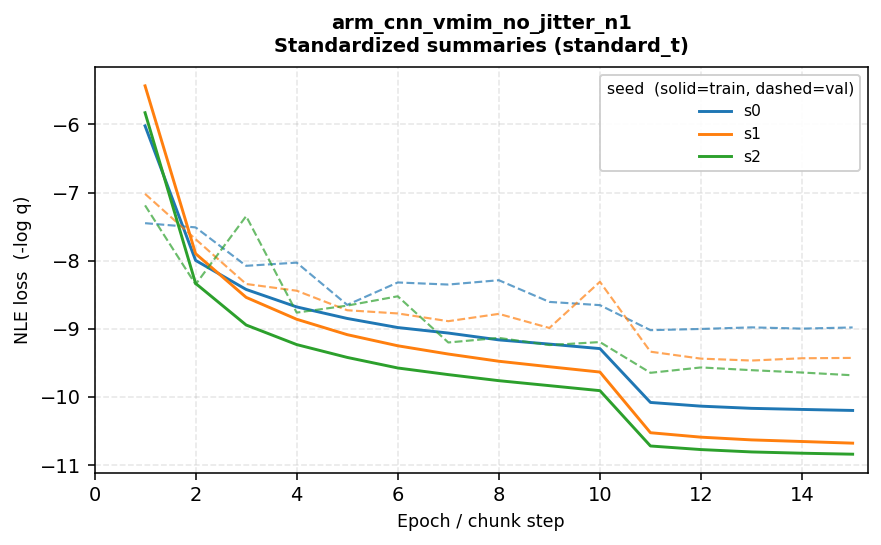

In [4]:
seeds = " ".join(map(str, SEEDS))
fig = OUT / "nle_training.png"
!python tools/plot_training_nle.py "{CONFIG}" --seeds {seeds} --models {FAMILY} --out "{fig}"
show(fig)

## 3. Final evaluation — stage 4 (all seeds overlaid)
`eval.py --all-seeds --seeds ...` expands the single item into one arm per
seed found on disk and overlays them on **every** figure (SBC, corner) and in
the metrics table.

> **Prerequisite:** stage 4 reads MCMC chains, so stages **1→2→3** must have
> finished for each seed (i.e. you launched with `STAGES=123`, not just `1`).
> If a seed has no `chains/` yet, eval prints `no .dat ... skipped` for it.

[all-seeds] cnn_vmim_/n1/seed [standard_t_nsf] -> seeds [0, 1, 2]
arms:
   VMIM n4 s0                   <- seed_s0[standard_t_nsf]  (/gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s0/chains/standard_t_nsf)
   VMIM n4 s1                   <- seed_s1[standard_t_nsf]  (/gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s1/chains/standard_t_nsf)
   VMIM n4 s2                   <- seed_s2[standard_t_nsf]  (/gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1/seed_s2/chains/standard_t_nsf)
shared sims across arms: 908
[mode] filtered dlogp10
[table] wrote notebooks/_figs/eval/metrics.csv  (filtered dlogp10)
[table] wrote notebooks/_figs/eval/metrics.tex

=== GV (median sqrt|Sigma_4x4|) / sigma (median IQR) / chi^2-to-flat ===
  VMIM n4 s0                 N= 908 GV=8.261e-10 sigma=[0.004, 0.0113, 0.0176, 0.0086] chi2=[0.03, 0.02, 0.032, 0.027]
  VMIM n4 s1                 N= 908 GV=5.389e-10 sigma=[0.004, 0.0076, 0.0177, 0.0062] chi2=[0.038, 0.058, 0.041, 0.067]
  VMIM n4 s2         

,,,,,,,,,,# mode: filtered dlogp10
arm,n_used,GV_4x4,sigma_0,sigma_1,sigma_2,sigma_3,calib_0,calib_1,calib_2,calib_3
seed_s0[standard_t_nsf],908,8.260896e-10,3.998921e-03,1.130378e-02,1.755977e-02,8.638608e-03,0.0299,0.0196,0.0320,0.0269
seed_s1[standard_t_nsf],908,5.389141e-10,3.980015e-03,7.637966e-03,1.766276e-02,6.205615e-03,0.0381,0.0577,0.0408,0.0670
seed_s2[standard_t_nsf],908,4.048483e-10,3.348134e-03,9.694202e-03,1.259968e-02,7.743997e-03,0.0367,0.0457,0.0414,0.0354


corner_sim878.pdf


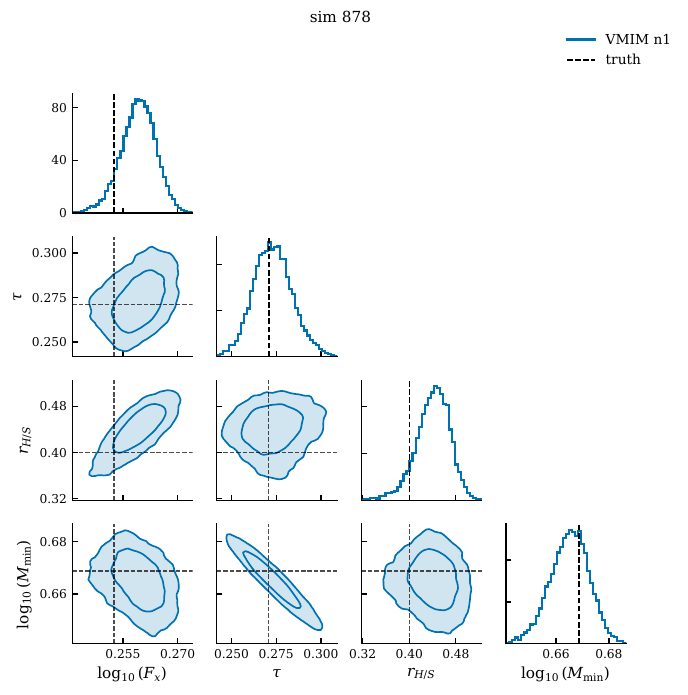

corner_sim909.pdf


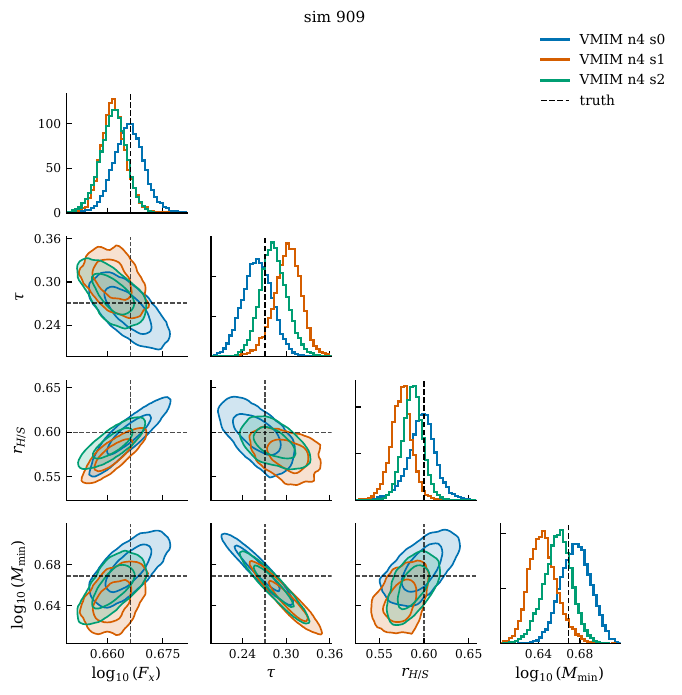

sbc_filtered_dlogp10.pdf


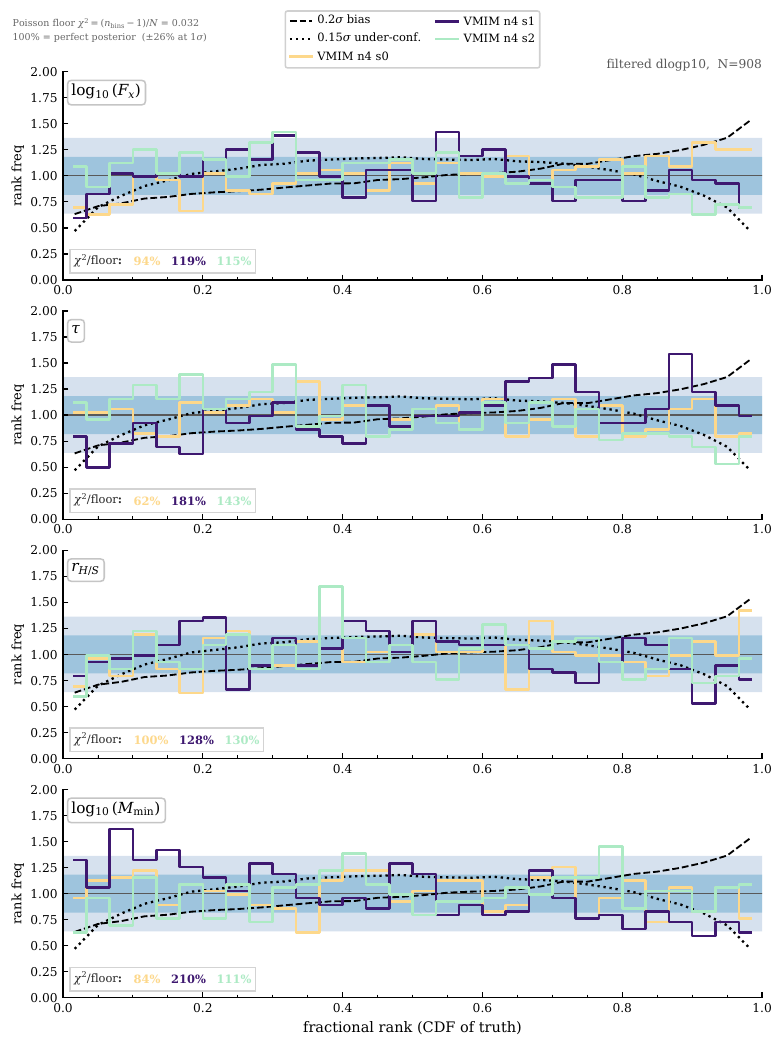

In [5]:
evdir = OUT / "eval"
seeds = " ".join(map(str, SEEDS))
!python eval.py --item "{CONFIG}|{FAMILY}|{SCOPE}|{LABEL}" \
        --all-seeds --seeds {seeds} --out "{evdir}"

# metrics table (one row per seed)
try:
    import pandas as pd

    mcsv = evdir / "metrics.csv"
    if mcsv.exists():
        display(pd.read_csv(mcsv))
except Exception as e:
    print("metrics table skipped:", e)

# every figure has all seeds overlaid
for p in sorted(glob.glob(str(evdir / "*.pdf"))):
    print(os.path.basename(p))
    show(p)

---
*Figures are written under `notebooks/_figs/` (git-ignored). Keep this
notebook's saved outputs when committing so the Jupyter Book shows them.*